# Notebook 07 - Transformer

En este notebook implementamos un Transformer sencillo para clasificación de actividades. El Transformer es la arquitectura detrás de modelos como BERT y GPT, y se basa en el mecanismo de atención en lugar de recurrencia.

## 1. Importaciones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import json
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization,
    MultiHeadAttention, GlobalAveragePooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

np.random.seed(42)
tf.random.set_seed(42)
print('TensorFlow:', tf.__version__)

TensorFlow: 2.21.0


## 2. Carga de Datos

In [2]:
DATA_DIR = '../data/processed'

X_tr = np.load(os.path.join(DATA_DIR, 'X_tr_seq.npy'))
X_val = np.load(os.path.join(DATA_DIR, 'X_val_seq.npy'))
X_test = np.load(os.path.join(DATA_DIR, 'X_test_seq.npy'))

y_tr = np.load(os.path.join(DATA_DIR, 'y_tr_seq.npy'))
y_val = np.load(os.path.join(DATA_DIR, 'y_val_seq.npy'))
y_test = np.load(os.path.join(DATA_DIR, 'y_test_seq.npy'))

y_test_int = np.load(os.path.join(DATA_DIR, 'y_test_int.npy'))

nombres_clases = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']

print('Train:', X_tr.shape)
print('Validation:', X_val.shape)
print('Test:', X_test.shape)

Train: (5881, 128, 9)
Validation: (1471, 128, 9)
Test: (2947, 128, 9)


## 3. ¿Cómo funciona el Transformer?

El Transformer reemplaza la recurrencia con el mecanismo de **atención multi-cabeza (Multi-Head Attention)**.

**Atención**: permite que cada paso de tiempo "mire" a todos los demás pasos de tiempo directamente. Para cada posición, calcula qué tan relevantes son las demás posiciones:

```
Attention(Q, K, V) = softmax(Q * K^T / sqrt(d_k)) * V
```

Donde Q (Query), K (Key) y V (Value) son proyecciones lineales de la entrada.

**Ventajas sobre RNN:**
- Procesa toda la secuencia en paralelo (más rápido de entrenar).
- Puede capturar dependencias entre posiciones distantes directamente.
- No sufre del problema del gradiente desvaneciente.

## 4. Implementación del Transformer

Implementamos un bloque Transformer sencillo usando la API funcional de Keras.

In [3]:
def bloque_transformer(x, num_heads, dim_ff, dropout_rate):
    """
    Un bloque Transformer básico:
    - Multi-Head Attention
    - Add & Norm
    - Feed Forward
    - Add & Norm
    """
    # Dimensión del modelo (dada por la entrada)
    dim_modelo = x.shape[-1]

    # Multi-Head Attention
    atencion = MultiHeadAttention(num_heads=num_heads, key_dim=dim_modelo // num_heads)(x, x)
    atencion = Dropout(dropout_rate)(atencion)
    # Conexión residual + normalización
    x = LayerNormalization(epsilon=1e-6)(x + atencion)

    # Feed Forward (dos capas densas)
    ff = Dense(dim_ff, activation='relu')(x)
    ff = Dropout(dropout_rate)(ff)
    ff = Dense(dim_modelo)(ff)
    # Conexión residual + normalización
    x = LayerNormalization(epsilon=1e-6)(x + ff)

    return x

print('Función de bloque Transformer definida')

Función de bloque Transformer definida


In [4]:
# Construcción del modelo completo
def construir_transformer(input_shape, num_clases, dim_proyeccion=64, num_heads=4, dim_ff=128, dropout=0.1):
    """
    Transformer completo para clasificación de series de tiempo.
    input_shape: (timesteps, features)
    """
    entradas = Input(shape=input_shape)

    # Proyección de entrada al tamaño del modelo
    # (128, 9) -> (128, 64)
    x = Dense(dim_proyeccion)(entradas)

    # Bloque Transformer 1
    x = bloque_transformer(x, num_heads=num_heads, dim_ff=dim_ff, dropout_rate=dropout)

    # Bloque Transformer 2
    x = bloque_transformer(x, num_heads=num_heads, dim_ff=dim_ff, dropout_rate=dropout)

    # Promedio global sobre el eje temporal
    # (128, 64) -> (64,)
    x = GlobalAveragePooling1D()(x)

    # Clasificador final
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    salidas = Dense(num_clases, activation='softmax')(x)

    return Model(inputs=entradas, outputs=salidas)


modelo_transformer = construir_transformer(input_shape=(128, 9), num_clases=6)
modelo_transformer.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128, 64)   │        640 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 64)   │     16,640 │ dense[0][0],      │
│ (MultiHeadAttentio… │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 64)   │          0 │ dense[0][0],      │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 128, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128, 128)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128, 64)   │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 64)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 128, 64)   │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 128, 64)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128, 128)  │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128, 64)   │      8,256 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 128, 64)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128, 64)   │        128 │ add_3[0][0]     

 Total params: 72,134 (281.77 KB)

 Trainable params: 72,134 (281.77 KB)

 Non-trainable params: 0 (0.00 B)

El modelo proyecta la entrada de 9 canales a 64 dimensiones, luego aplica 2 bloques Transformer, y finalmente hace promedio global sobre la dimensión temporal para obtener un vector de clasificación. Este diseño es simple pero efectivo.

## 5. Entrenamiento

In [5]:
 modelo_transformer.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

inicio = time.time()

historial = modelo_transformer.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

tiempo_entrenamiento = time.time() - inicio
print(f'\nTiempo de entrenamiento: {tiempo_entrenamiento:.2f} segundos')

Epoch 1/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 51s 298ms/step - accuracy: 0.7545 - loss: 0.6212 - val_accuracy: 0.9055 - val_loss: 0.2467
Epoch 2/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 232ms/step - accuracy: 0.9230 - loss: 0.2121 - val_accuracy: 0.9531 - val_loss: 0.1313
Epoch 3/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 233ms/step - accuracy: 0.9429 - loss: 0.1496 - val_accuracy: 0.9619 - val_loss: 0.1115
Epoch 4/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 233ms/step - accuracy: 0.9405 - loss: 0.1442 - val_accuracy: 0.9517 - val_loss: 0.1064
Epoch 5/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 224ms/step - accuracy: 0.9475 - loss: 0.1207 - val_accuracy: 0.9585 - val_loss: 0.1038
Epoch 6/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 231ms/step - accuracy: 0.9469 - loss: 0.1192 - val_accuracy: 0.9497 - val_loss: 0.1039
Epoch 7/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 228ms/step - accuracy: 0.9473 - loss: 0.1233 - val_accuracy: 0.9633 - val_loss: 0.0926
Epoch 8/80
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 225ms/step - accuracy: 0.9548 - loss: 0.1063 - val_accu

## 6. Curvas de Aprendizaje

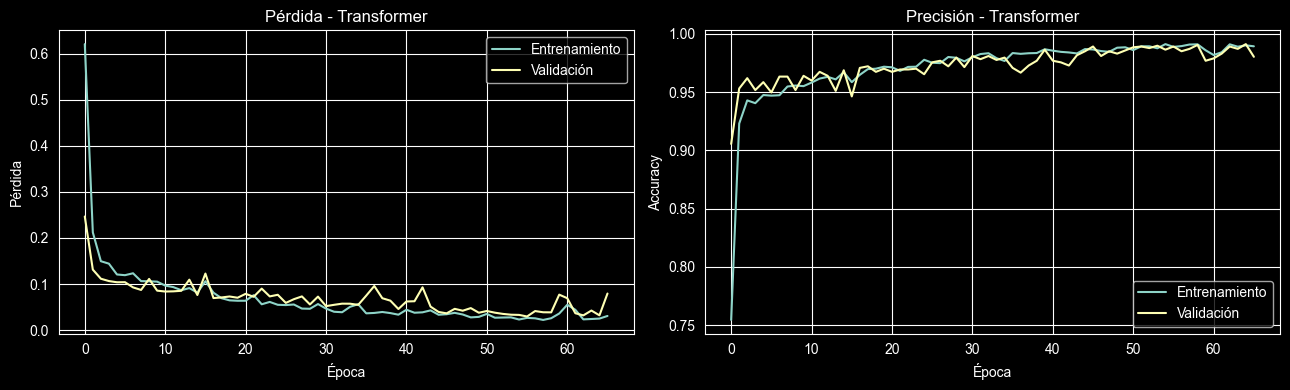

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(historial.history['loss'], label='Entrenamiento')
axes[0].plot(historial.history['val_loss'], label='Validación')
axes[0].set_title('Pérdida - Transformer')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida')
axes[0].legend()

axes[1].plot(historial.history['accuracy'], label='Entrenamiento')
axes[1].plot(historial.history['val_accuracy'], label='Validación')
axes[1].set_title('Precisión - Transformer')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/curvas_transformer.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Evaluación

In [7]:
y_pred_prob = modelo_transformer.predict(X_test)
y_pred_int = np.argmax(y_pred_prob, axis=1)

acc = accuracy_score(y_test_int, y_pred_int)
print(f'Accuracy en Test: {acc:.4f}\n')
print(classification_report(y_test_int, y_pred_int, target_names=nombres_clases))

93/93 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step
Accuracy en Test: 0.9220

                    precision    recall  f1-score   support

           WALKING       0.97      0.87      0.92       496
  WALKING_UPSTAIRS       0.93      0.94      0.94       471
WALKING_DOWNSTAIRS       0.85      0.95      0.90       420
           SITTING       0.94      0.82      0.88       491
          STANDING       0.89      0.94      0.91       532
            LAYING       0.96      1.00      0.98       537

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947



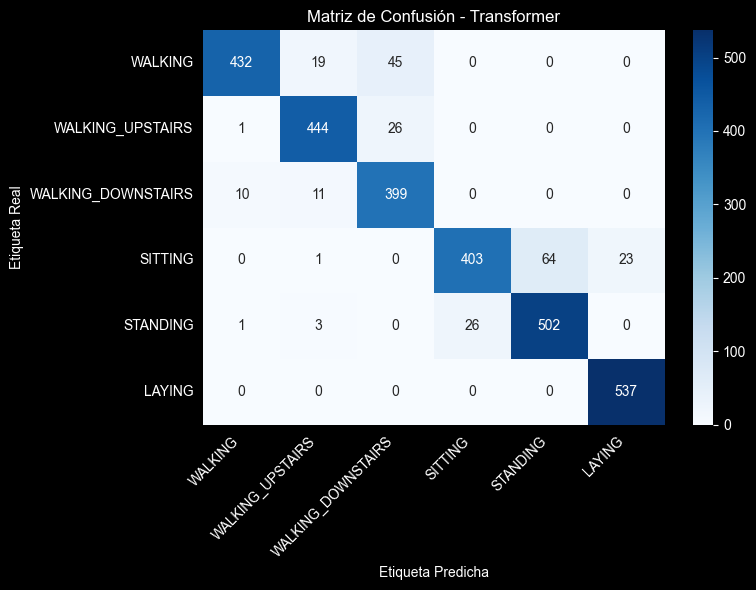

In [8]:
cm = confusion_matrix(y_test_int, y_pred_int)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de Confusión - Transformer')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/cm_transformer.png', dpi=100, bbox_inches='tight')
plt.show()

In [9]:
metricas_transformer = {
    'modelo': 'Transformer',
    'accuracy': accuracy_score(y_test_int, y_pred_int),
    'precision': precision_score(y_test_int, y_pred_int, average='weighted'),
    'recall': recall_score(y_test_int, y_pred_int, average='weighted'),
    'f1': f1_score(y_test_int, y_pred_int, average='weighted'),
    'tiempo_entrenamiento': tiempo_entrenamiento
}

for k, v in metricas_transformer.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

with open('../models/metricas_transformer.json', 'w') as f:
    json.dump(metricas_transformer, f)

modelo_transformer.save('../models/modelo_transformer.keras')
print('\nGuardado.')

  modelo: Transformer
  accuracy: 0.9220
  precision: 0.9246
  recall: 0.9220
  f1: 0.9215
  tiempo_entrenamiento: 1472.5872

Guardado.


## Conclusiones del Modelo Transformer

El Transformer demuestra ser una alternativa poderosa a los modelos recurrentes:

**Ventajas:**
- **Paralelización**: a diferencia de RNN/LSTM/GRU, procesa todos los pasos de tiempo simultáneamente, lo que permite aprovechar mejor las GPUs.
- **Atención global**: puede relacionar directamente el primer y el último paso de tiempo sin pasar por todos los estados intermedios.
- **Sin gradiente desvaneciente** en el mismo sentido que las RNNs, ya que la información fluye directamente a través de las conexiones residuales.

**Limitaciones:**
- Requiere más datos para entrenar bien que los modelos recurrentes.
- La complejidad cuadrática de la atención ($O(n^2)$) puede ser costosa para secuencias muy largas.
- Es más difícil de interpretar y ajustar que una LSTM.

En nuestro problema con 128 pasos de tiempo, el Transformer funciona bien y es competitivo con LSTM y GRU.